In [29]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as  plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv(r"c:\Users\Lenovo\Downloads\dummy_data.csv")

In [31]:
df.head()

,age,gender,time_spent,platform,interests,location,demographics,profession,income,indebt,isHomeOwner,Owns_Car
0,56,male,3,Instagram,Sports,United Kingdom,Urban,Software Engineer,19774,True,False,False
1,46,female,2,Facebook,Travel,United Kingdom,Urban,Student,10564,True,True,True
2,32,male,8,Instagram,Sports,Australia,Sub_Urban,Marketer Manager,13258,False,False,False
3,60,non-binary,5,Instagram,Travel,United Kingdom,Urban,Student,12500,False,True,False
4,25,male,1,Instagram,Lifestlye,Australia,Urban,Software Engineer,14566,False,True,True


In [32]:
df.dtypes

age              int64
gender          object
time_spent       int64
platform        object
interests       object
location        object
demographics    object
profession      object
income           int64
indebt            bool
isHomeOwner       bool
Owns_Car          bool
dtype: object

In [33]:
df.isnull().sum()

age             0
gender          0
time_spent      0
platform        0
interests       0
location        0
demographics    0
profession      0
income          0
indebt          0
isHomeOwner     0
Owns_Car        0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe()

,age,time_spent,income
count,1000.000000,1000.000000,1000.000000
mean,40.986000,5.029000,15014.823000
std,13.497852,2.537834,2958.628221
min,18.000000,1.000000,10012.000000
25%,29.000000,3.000000,12402.250000
50%,42.000000,5.000000,14904.500000
75%,52.000000,7.000000,17674.250000
max,64.000000,9.000000,19980.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           1000 non-null   int64 
 1   gender        1000 non-null   object
 2   time_spent    1000 non-null   int64 
 3   platform      1000 non-null   object
 4   interests     1000 non-null   object
 5   location      1000 non-null   object
 6   demographics  1000 non-null   object
 7   profession    1000 non-null   object
 8   income        1000 non-null   int64 
 9   indebt        1000 non-null   bool  
 10  isHomeOwner   1000 non-null   bool  
 11  Owns_Car      1000 non-null   bool  
dtypes: bool(3), int64(3), object(6)
memory usage: 73.4+ KB


In [37]:
df['indebt'] = df['indebt'].apply(lambda x: 1  if x==True else 0).astype(int)
df['isHomeOwner'] = df['isHomeOwner'].apply(lambda x: 1 if x== True else 0 ).astype(int)
df['Owns_Car'] = df['Owns_Car'].apply(lambda x: 1 if x==True else 0 ).astype(int)

In [38]:
df.head()

,age,gender,time_spent,platform,interests,location,demographics,profession,income,indebt,isHomeOwner,Owns_Car
0,56,male,3,Instagram,Sports,United Kingdom,Urban,Software Engineer,19774,1,0,0
1,46,female,2,Facebook,Travel,United Kingdom,Urban,Student,10564,1,1,1
2,32,male,8,Instagram,Sports,Australia,Sub_Urban,Marketer Manager,13258,0,0,0
3,60,non-binary,5,Instagram,Travel,United Kingdom,Urban,Student,12500,0,1,0
4,25,male,1,Instagram,Lifestlye,Australia,Urban,Software Engineer,14566,0,1,1


##Data visualization 

Data become meaningfull when visualized

age,time spent and income distribution


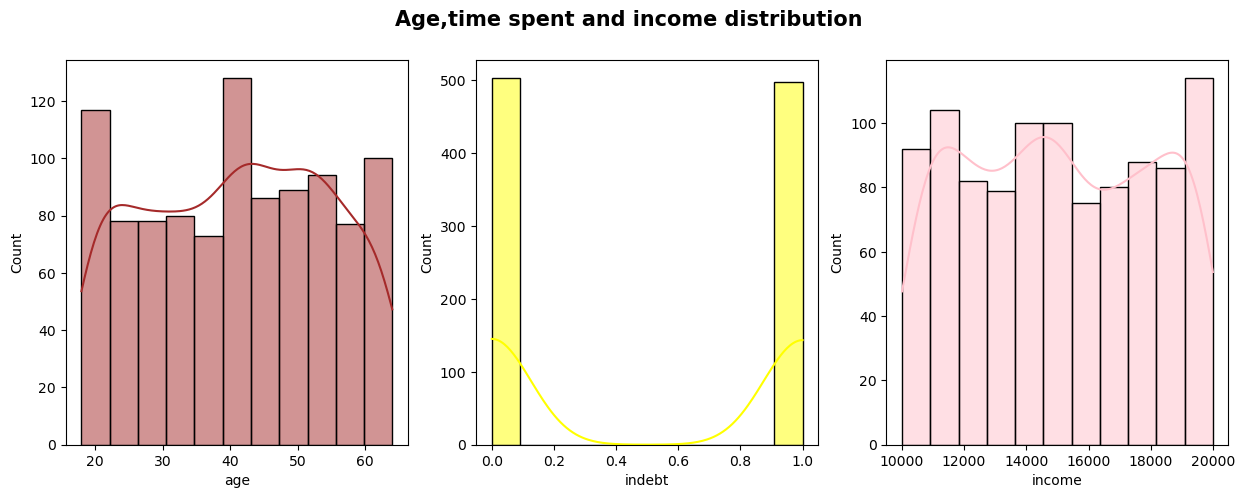

In [39]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
sns.histplot(df['age'],kde=True,color='brown',ax=ax[0])
sns.histplot(df['indebt'],kde=True,color='yellow',ax=ax[1])
sns.histplot(df['income'],kde=True,color='pink',ax=ax[2])
plt.suptitle('Age,time spent and income distribution',fontsize=15,weight='bold')
plt.show()

gender and platfrom distribution

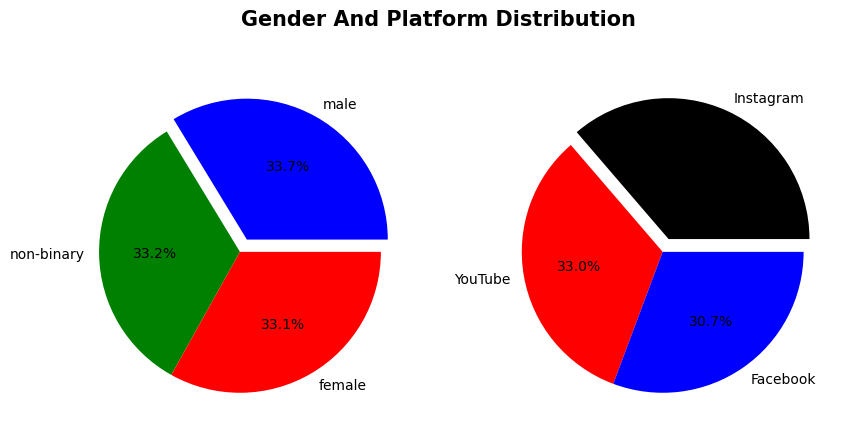

In [43]:
gender_count = df['gender'].value_counts()
platform_count = df['platform'].value_counts()

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].pie(gender_count,labels=gender_count.index,autopct='%1.1f%%',colors=['blue','green','red'],explode= [0.1,0,0])
ax[1].pie(platform_count,labels=platform_count.index,autopct='%1.1f%%' , colors = ['black','red','blue'] , explode= [0.1,0,0])
plt.suptitle('Gender And Platform Distribution',fontsize=15, weight='bold')
plt.show()

average time spent by gender 


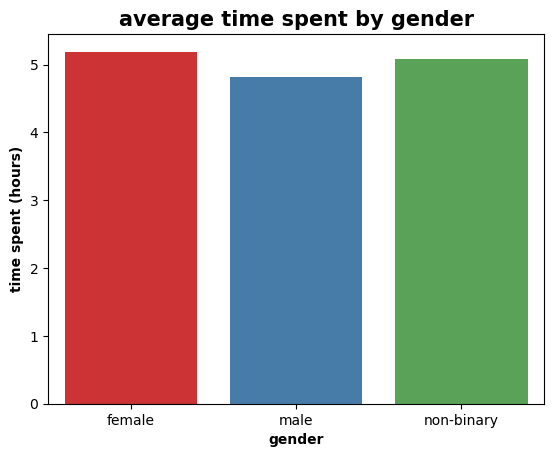

In [45]:
gender_avg_time_spent = df.groupby('gender')['time_spent'].mean()
sns.barplot(x=gender_avg_time_spent.index,y=gender_avg_time_spent.values,palette='Set1')
plt.ylabel('time spent (hours)',weight='bold')
plt.xlabel('gender',weight='bold')
plt.title('average time spent by gender',fontsize=15,weight='bold')
plt.show()

avg time spent on platform

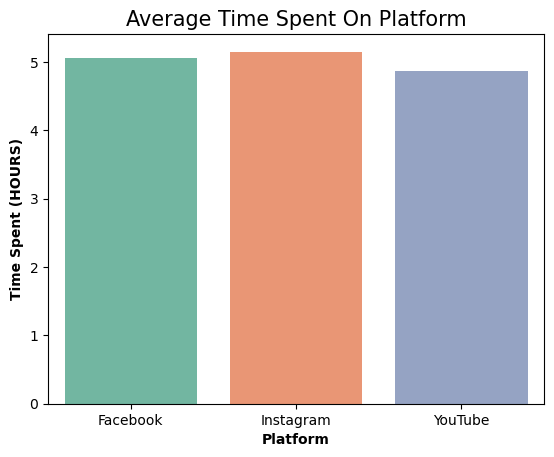

In [50]:
avgtime_spent_platform = df.groupby('platform')['time_spent'].mean()
sns.barplot(x=avgtime_spent_platform.index,y=avgtime_spent_platform.values,palette='Set2')
plt.ylabel('Time Spent (HOURS)', weight='bold')
plt.xlabel('Platform', weight='bold')
plt.title('Average Time Spent On Platform',fontsize=15)
plt.show()

age vs  time spent


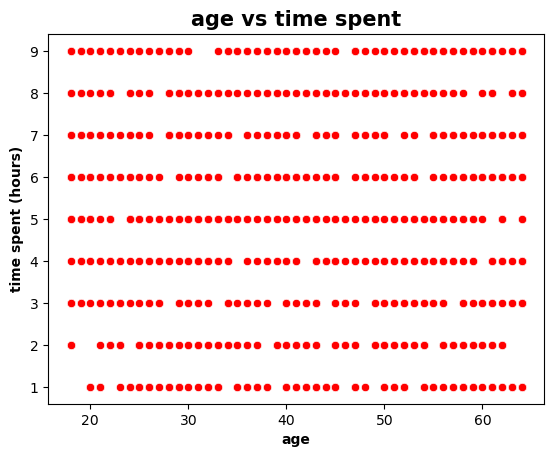

In [52]:
sns.scatterplot(x='age',y='time_spent',data=df,color='red')
plt.title("age vs time spent",fontsize=15,weight='bold')
plt.ylabel('time spent (hours)',weight='bold')
plt.xlabel('age',weight='bold')
plt.show()

avg time spent vs location 

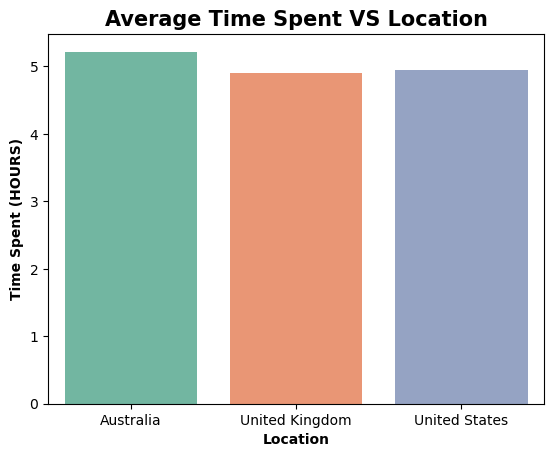

In [53]:
location_timespent = df.groupby('location')['time_spent'].mean()
sns.barplot(x=location_timespent.index,y=location_timespent.values,palette='Set2')
plt.ylabel('Time Spent (HOURS)', weight='bold')
plt.xlabel('Location', weight='bold')
plt.title('Average Time Spent VS Location',fontsize=15, weight='bold')
plt.show()

avg time spent vs profession 

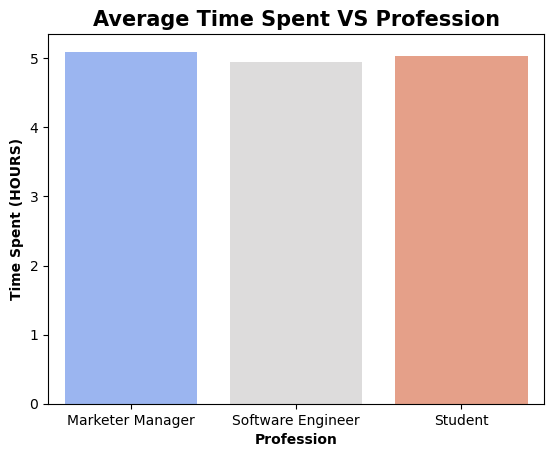

In [54]:
profession_timespent = df.groupby('profession')['time_spent'].mean()
sns.barplot(x=profession_timespent.index,y=profession_timespent.values,palette='coolwarm')
plt.ylabel('Time Spent (HOURS)', weight='bold')
plt.xlabel('Profession', weight='bold')
plt.title('Average Time Spent VS Profession',fontsize=15, weight='bold')
plt.show()

avg time spent vs interest

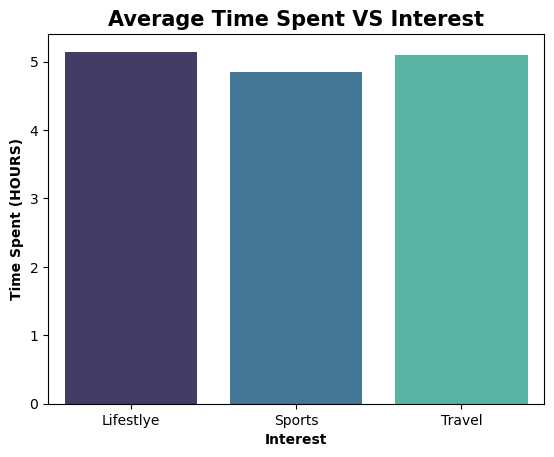

In [55]:
interest_timespent = df.groupby('interests')['time_spent'].mean()
sns.barplot(x=interest_timespent.index,y=interest_timespent.values,palette='mako')
plt.ylabel('Time Spent (HOURS)', weight='bold')
plt.xlabel('Interest', weight='bold')
plt.title('Average Time Spent VS Interest',fontsize=15, weight='bold')
plt.show()

correlation matrix

Text(0.5, 1.0, 'correlation matrix')

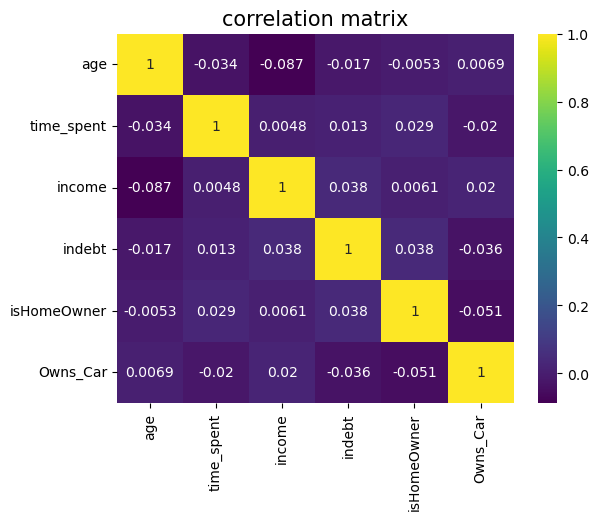

In [56]:
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr,annot=True,cmap='viridis')
plt.title('correlation matrix',fontsize=15)